Loading Dataset...
Dataset Loaded Successfully
Total Images: 999
X Shape: (999, 224, 224, 3)
Y Shape: (999,)
Training: (699, 224, 224, 3)
Validation: (150, 224, 224, 3)
Testing: (150, 224, 224, 3)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,619,074 (9.99 MB)

 Trainable params: 361,090 (1.38 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training Started...
Epoch 1/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 319ms/step - accuracy: 0.6362 - loss: 0.7518
Epoch 1: val_accuracy improved from None to 0.78000, saving model to C:\\Users\\user\\Desktop\\computer vision project\\best_fire_model.keras

Epoch 1: finished saving model to C:\\Users\\user\\Desktop\\computer vision project\\best_fire_model.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 11s 411ms/step - accuracy: 0.7139 - loss: 0.6326 - val_accuracy: 0.7800 - val_loss: 0.3917 - learning_rate: 1.0000e-04
Epoch 2/25
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.8119 - loss: 0.3964
Epoch 2: val_accuracy improved from 0.78000 to 0.87333, saving model to C:\\Users\\user\\Desktop\\computer vision project\\best_fire_model.keras

Epoch 2: finished saving model to C:\\Users\\user\\Desktop\\computer vision project\\best_fire_model.keras
22/22 ━━━━━━━━━━━━━━━━━━━━ 8s 373ms/step - accuracy: 0.8412 - loss: 0.3684 - val_accuracy: 0.8733 - val_loss: 0.2395 - learning_rate: 1.0000e-04
Epoch 3/25
22/

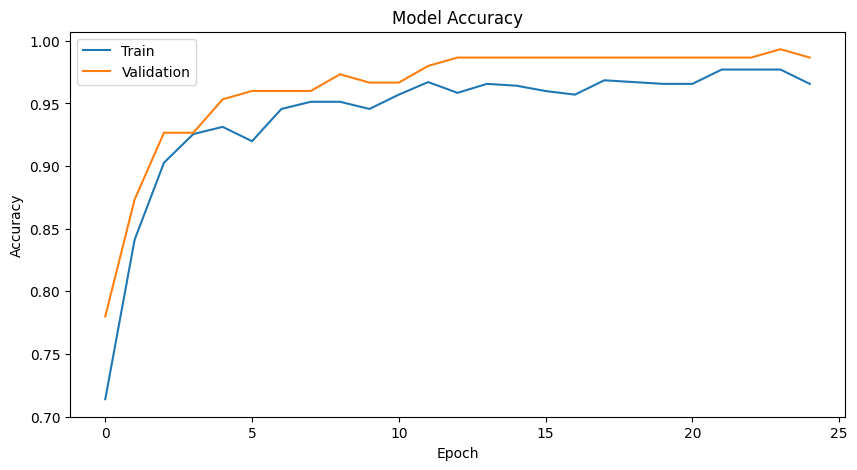

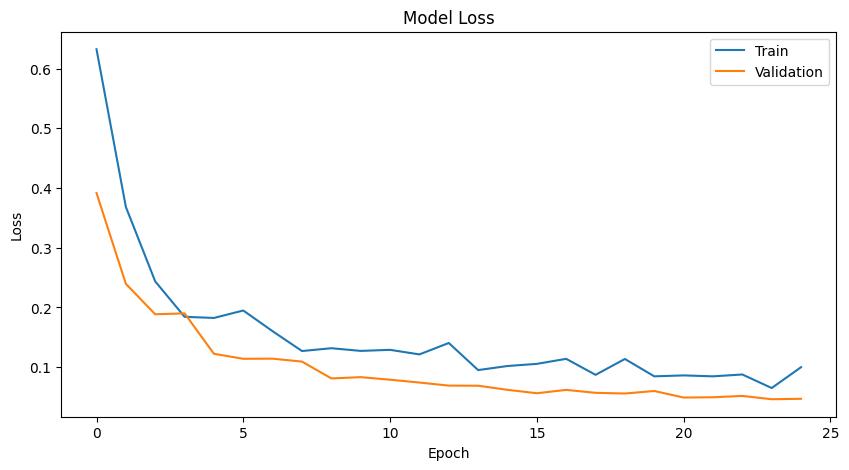

5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 213ms/step - accuracy: 0.9800 - loss: 0.0583

Test Accuracy: 0.9800000190734863
Test Loss: 0.058299485594034195
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 323ms/step


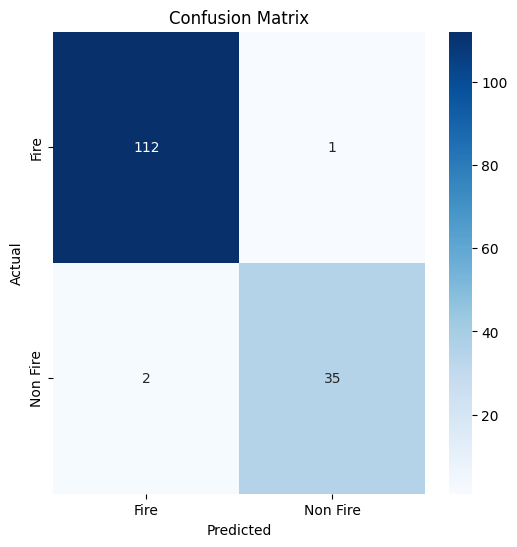


Classification Report:

              precision    recall  f1-score   support

        Fire       0.98      0.99      0.99       113
    Non Fire       0.97      0.95      0.96        37

    accuracy                           0.98       150
   macro avg       0.98      0.97      0.97       150
weighted avg       0.98      0.98      0.98       150

Model Saved Successfully
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 720ms/step


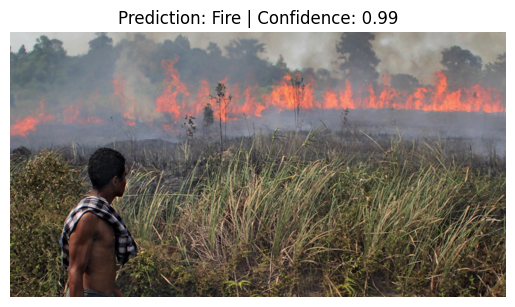

Prediction: Fire
Confidence: 0.99185187


In [3]:
# =========================================================
# 🔥 ADVANCED FIRE DETECTION SYSTEM
# =========================================================

# -------------------------------------------------
# 1. IMPORT LIBRARIES
# -------------------------------------------------

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D
)

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.utils import to_categorical

from tensorflow.keras.applications import MobileNetV2

from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint
)

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    confusion_matrix,
    classification_report
)


# -------------------------------------------------
# 2. DATASET PATH
# -------------------------------------------------

DATASET_PATH = r"C:\\Users\\user\\Desktop\\computer vision project\\fire_dataset"

categories = ["fire_images", "non_fire_images"]

IMG_SIZE = 224

data = []

labels = []


# -------------------------------------------------
# 3. LOAD DATASET
# -------------------------------------------------

print("Loading Dataset...")

for category in categories:

    folder_path = os.path.join(DATASET_PATH, category)

    label = categories.index(category)

    for img_name in os.listdir(folder_path):

        img_path = os.path.join(folder_path, img_name)

        try:

            img = cv2.imread(img_path)

            if img is None:
                continue

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            data.append(img)

            labels.append(label)

        except Exception as e:

            print("Error Loading:", img_path)

print("Dataset Loaded Successfully")

print("Total Images:", len(data))


# -------------------------------------------------
# 4. CONVERT TO NUMPY ARRAY
# -------------------------------------------------

X = np.array(data, dtype="float32")

Y = np.array(labels)

print("X Shape:", X.shape)

print("Y Shape:", Y.shape)


# -------------------------------------------------
# 5. PREPROCESS INPUT
# -------------------------------------------------

X = preprocess_input(X)


# -------------------------------------------------
# 6. ONE HOT ENCODING
# -------------------------------------------------

Y = to_categorical(Y, num_classes=2)


# -------------------------------------------------
# 7. TRAIN TEST SPLIT
# -------------------------------------------------

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    Y,
    test_size=0.30,
    random_state=42,
    stratify=Y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)

print("Validation:", X_val.shape)

print("Testing:", X_test.shape)


# -------------------------------------------------
# 8. DATA AUGMENTATION
# -------------------------------------------------

train_datagen = ImageDataGenerator(
    rotation_range=30,
    zoom_range=0.3,
    horizontal_flip=True,
    width_shift_range=0.3,
    height_shift_range=0.3,
    brightness_range=[0.7, 1.3]
)


# -------------------------------------------------
# 9. LOAD MOBILENETV2
# -------------------------------------------------

base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False


# -------------------------------------------------
# 10. BUILD MODEL
# -------------------------------------------------

model = Sequential()

model.add(base_model)

model.add(GlobalAveragePooling2D())

model.add(Dense(256, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

model.add(Dense(2, activation='softmax'))

model.summary()


# -------------------------------------------------
# 11. COMPILE MODEL
# -------------------------------------------------

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


# -------------------------------------------------
# 12. CALLBACKS
# -------------------------------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1
)

checkpoint = ModelCheckpoint(
    r"C:\\Users\\user\\Desktop\\computer vision project\\best_fire_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)


# -------------------------------------------------
# 13. TRAIN MODEL
# -------------------------------------------------

print("Training Started...")

history = model.fit(
    train_datagen.flow(
        X_train,
        y_train,
        batch_size=32
    ),

    validation_data=(X_val, y_val),

    epochs=25,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint
    ]
)

print("Training Completed")


# -------------------------------------------------
# 14. ACCURACY GRAPH
# -------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'])

plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.legend(["Train", "Validation"])

plt.show()


# -------------------------------------------------
# 15. LOSS GRAPH
# -------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(history.history['loss'])

plt.plot(history.history['val_loss'])

plt.title("Model Loss")

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.legend(["Train", "Validation"])

plt.show()


# -------------------------------------------------
# 16. EVALUATE MODEL
# -------------------------------------------------

loss, accuracy = model.evaluate(X_test, y_test)

print("\nTest Accuracy:", accuracy)

print("Test Loss:", loss)


# -------------------------------------------------
# 17. PREDICTIONS
# -------------------------------------------------

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

y_true = np.argmax(y_test, axis=1)


# -------------------------------------------------
# 18. CONFUSION MATRIX
# -------------------------------------------------

cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(6,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Fire', 'Non Fire'],
    yticklabels=['Fire', 'Non Fire']
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()


# -------------------------------------------------
# 19. CLASSIFICATION REPORT
# -------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_true,
        y_pred_classes,
        target_names=['Fire', 'Non Fire']
    )
)


# -------------------------------------------------
# 20. SAVE MODEL
# -------------------------------------------------

model.save(
    r"C:\\Users\\user\\Desktop\\computer vision project\\fire_detection_model.keras"
)

print("Model Saved Successfully")


# -------------------------------------------------
# 21. LOAD MODEL
# -------------------------------------------------

model = load_model(
    r"C:\\Users\\user\\Desktop\\computer vision project\\best_fire_model.keras"
)


# -------------------------------------------------
# 22. PREDICT IMAGE
# -------------------------------------------------

IMG_SIZE = 224

classes = ['Fire', 'Non Fire']


def predict_image(image_path):

    img = cv2.imread(image_path)

    if img is None:
        print("Image not found!")
        return

    img_rgb = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    resized = cv2.resize(
        img_rgb,
        (IMG_SIZE, IMG_SIZE)
    )

    image_array = np.array(
        resized,
        dtype='float32'
    )

    image_array = preprocess_input(image_array)

    reshaped = np.reshape(
        image_array,
        (1, IMG_SIZE, IMG_SIZE, 3)
    )

    prediction = model.predict(reshaped)

    class_index = np.argmax(prediction)

    confidence = np.max(prediction)

    label = classes[class_index]

    plt.imshow(img_rgb)

    plt.title(
        f"Prediction: {label} | Confidence: {confidence:.2f}"
    )

    plt.axis("off")

    plt.show()

    print("Prediction:", label)

    print("Confidence:", confidence)


# -------------------------------------------------
# 23. TEST IMAGE
# -------------------------------------------------

predict_image(
    r"C:\\Users\\user\\Desktop\\computer vision project\\fire_dataset\\fire_images\\fire.1.png"
)